# DenseNet121 — Evaluation Only (No Training)
Kaydedilmiş modelleri yükleyip test seti üzerinde değerlendirme yapar.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, roc_curve
)

print('Imports OK')

Imports OK


In [2]:
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print('Device:', device)

Device: cpu


In [3]:
base_path = '../data/'
test_dir  = os.path.join(base_path, 'test')

valid_test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Validation seti de lazım (validation accuracy için)
valid_dir   = os.path.join(base_path, 'valid')
valid_dataset = datasets.ImageFolder(valid_dir, transform=valid_test_transforms)
test_dataset  = datasets.ImageFolder(test_dir,  transform=valid_test_transforms)

valid_loader = DataLoader(valid_dataset, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

print('Test size:', len(test_dataset))
print('Classes:',  test_dataset.classes)

Test size: 1070
Classes: ['0', '1']


In [4]:
def build_densenet():
    model = models.densenet121(weights=None)
    model.features.conv0 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )
    model.classifier = nn.Linear(model.classifier.in_features, 2)
    return model


def evaluate_model(model, loader, device, epoch_label, threshold=0.4):
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_probs  = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds  = (all_probs >= threshold).astype(int)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec  = recall_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds)
    auc  = roc_auc_score(all_labels, all_probs)

    print(f'\n--- DenseNet121 {epoch_label} Test Results ---')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-Score : {f1:.4f}')
    print(f'ROC-AUC  : {auc:.4f}')

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'DenseNet121 {epoch_label} Confusion Matrix')
    os.makedirs('../outputs', exist_ok=True)
    tag = epoch_label.replace(' ', '_')
    plt.savefig(f'../outputs/densenet121_confusion_matrix_{tag}.png', bbox_inches='tight')
    plt.show()
    print(f'TN:{tn}  FP:{fp}  FN:{fn}  TP:{tp}')

    # ROC Curve
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'DenseNet121 {epoch_label} ROC Curve')
    plt.legend()
    plt.savefig(f'../outputs/densenet121_roc_curve_{tag}.png')
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'auc': auc}


def get_best_val_acc(model, loader, device):
    """Validation accuracy — tek pass, eğitim yok."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


print('Functions defined.')

Functions defined.


## 5 Epoch Model — Load & Evaluate

5 epoch model loaded.
Validation Accuracy (5ep): 90.65%

--- DenseNet121 5 Epoch Test Results ---
Accuracy : 0.9028
Precision: 0.9074
Recall   : 0.8972
F1-Score : 0.9023
ROC-AUC  : 0.9726


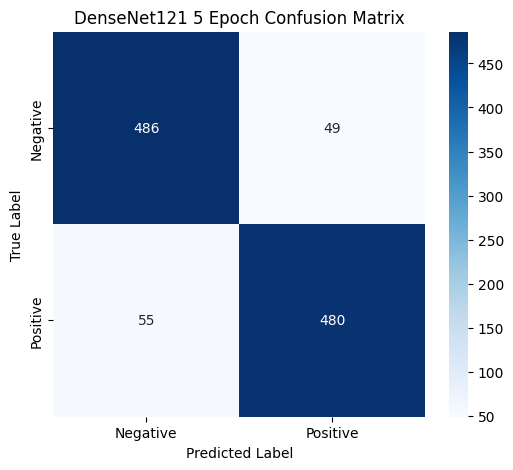

TN:486  FP:49  FN:55  TP:480


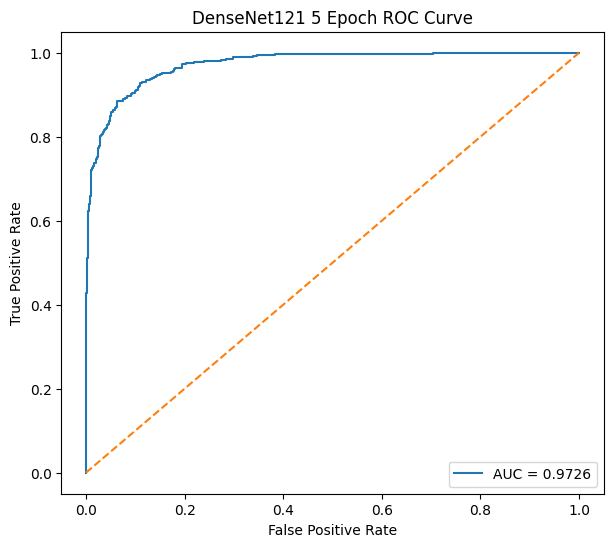

In [5]:
densenet_5ep = build_densenet()
densenet_5ep.load_state_dict(
    torch.load('../models/densenet121_chest_xray.pth', map_location=device)
)
densenet_5ep = densenet_5ep.to(device)
densenet_5ep.eval()
print('5 epoch model loaded.')

val_acc_5ep = get_best_val_acc(densenet_5ep, valid_loader, device)
print(f'Validation Accuracy (5ep): {val_acc_5ep:.2f}%')

metrics_5ep = evaluate_model(densenet_5ep, test_loader, device, '5 Epoch')

## 10 Epoch Model — Load & Evaluate

10 epoch model loaded.
Validation Accuracy (10ep): 92.71%

--- DenseNet121 10 Epoch Test Results ---
Accuracy : 0.9234
Precision: 0.9381
Recall   : 0.9065
F1-Score : 0.9221
ROC-AUC  : 0.9827


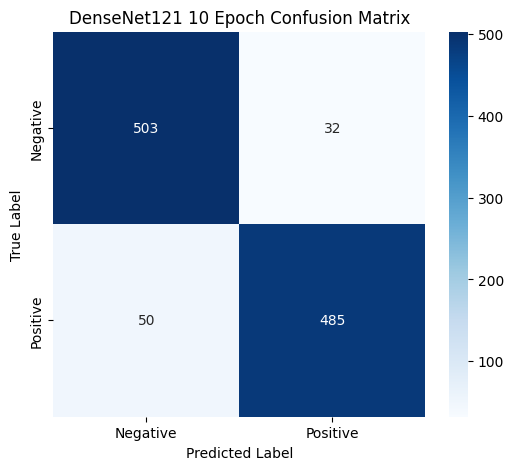

TN:503  FP:32  FN:50  TP:485


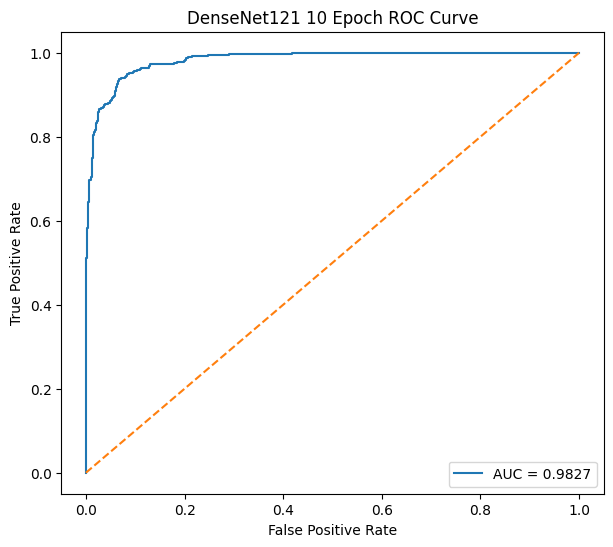

In [6]:
densenet_10ep = build_densenet()
densenet_10ep.load_state_dict(
    torch.load('../models/densenet121_chest_xray_10epoch.pth', map_location=device)
)
densenet_10ep = densenet_10ep.to(device)
densenet_10ep.eval()
print('10 epoch model loaded.')

val_acc_10ep = get_best_val_acc(densenet_10ep, valid_loader, device)
print(f'Validation Accuracy (10ep): {val_acc_10ep:.2f}%')

metrics_10ep = evaluate_model(densenet_10ep, test_loader, device, '10 Epoch')

In [ ]:
# ===== DENSENET121 — 5 vs 10 EPOCH VAL ACCURACY GRAPH =====

import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

def build_model():
    m = models.densenet121(weights=None)
    m.features.conv0 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.classifier = nn.Linear(m.classifier.in_features, 2)
    return m

valid_loader_graph = DataLoader(
    datasets.ImageFolder('../data/valid', transform=transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])),
    batch_size=8, shuffle=False
)

def checkpoint_val_acc(path):
    model = build_model()
    model.load_state_dict(torch.load(path, map_location=device))
    model = model.to(device)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in valid_loader_graph:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total

checkpoints = [
    (5,  '../models/densenet121_chest_xray.pth'),
    (10, '../models/densenet121_chest_xray_10epoch.pth'),
]

epochs_x, val_accs = [], []
for ep, path in checkpoints:
    if os.path.exists(path):
        acc = checkpoint_val_acc(path)
        epochs_x.append(ep)
        val_accs.append(acc)
        print(f'Epoch {ep:2d} => Val Acc: {acc:.2f}%')
    else:
        print(f'WARNING: {path} bulunamadi.')

plt.figure(figsize=(8, 5))
plt.plot(epochs_x, val_accs, marker='o', linewidth=2, color='steelblue', label='Validation Accuracy')
for x, y in zip(epochs_x, val_accs):
    plt.annotate(f'{y:.2f}%', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=11)
plt.title('DenseNet121 — Validation Accuracy: 5 vs 10 Epoch')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy (%)')
plt.xticks(epochs_x)
plt.ylim(min(val_accs) - 3, max(val_accs) + 4)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/densenet121_val_accuracy_5vs10.png', bbox_inches='tight')
plt.show()

In [ ]:
# ===== DENSENET121 — TRAINING HISTORY GRAPH (5 & 10 EPOCH) =====

import matplotlib.pyplot as plt
import os

# 5 Epoch eğitim değerleri
densenet_5ep_train_losses     = [0.5103, 0.3906, 0.3376, 0.3156, 0.2938]
densenet_5ep_valid_losses     = [0.3624, 0.2731, 0.2403, 0.2582, 0.2383]
densenet_5ep_train_accuracies = [73.97,  82.83,  86.05,  86.82,  88.46]
densenet_5ep_valid_accuracies = [84.21,  88.69,  89.44,  89.25,  90.65]

# 10 Epoch — scroll edip kalan epoch değerlerini gör, aşağıya ekle
# Şimdilik 5ep değerlerinin devamı olarak boş bırakıldı
densenet_10ep_train_losses     = []
densenet_10ep_valid_losses     = []
densenet_10ep_train_accuracies = []
densenet_10ep_valid_accuracies = []

os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 5 Epoch Loss ---
axes[0, 0].plot(densenet_5ep_train_losses, label='Train Loss', color='steelblue')
axes[0, 0].plot(densenet_5ep_valid_losses, label='Validation Loss', color='orange')
axes[0, 0].set_title('DenseNet121 5 Epoch Loss Analysis')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# --- 5 Epoch Accuracy ---
axes[0, 1].plot(densenet_5ep_train_accuracies, label='Train Accuracy', color='steelblue')
axes[0, 1].plot(densenet_5ep_valid_accuracies, label='Validation Accuracy', color='orange')
axes[0, 1].set_title('DenseNet121 5 Epoch Accuracy Analysis')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()

# --- 10 Epoch Loss ---
if densenet_10ep_train_losses:
    axes[1, 0].plot(densenet_10ep_train_losses, label='Train Loss', color='steelblue')
    axes[1, 0].plot(densenet_10ep_valid_losses, label='Validation Loss', color='orange')
    axes[1, 0].set_title('DenseNet121 10 Epoch Loss Analysis')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, '10 Epoch değerleri\nhücreye girilmedi',
                    ha='center', va='center', transform=axes[1, 0].transAxes, fontsize=12)
    axes[1, 0].set_title('DenseNet121 10 Epoch Loss Analysis')

# --- 10 Epoch Accuracy ---
if densenet_10ep_train_accuracies:
    axes[1, 1].plot(densenet_10ep_train_accuracies, label='Train Accuracy', color='steelblue')
    axes[1, 1].plot(densenet_10ep_valid_accuracies, label='Validation Accuracy', color='orange')
    axes[1, 1].set_title('DenseNet121 10 Epoch Accuracy Analysis')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
else:
    axes[1, 1].text(0.5, 0.5, '10 Epoch değerleri\nhücreye girilmedi',
                    ha='center', va='center', transform=axes[1, 1].transAxes, fontsize=12)
    axes[1, 1].set_title('DenseNet121 10 Epoch Accuracy Analysis')

plt.tight_layout()
plt.savefig('../outputs/densenet121_training_history.png', bbox_inches='tight')
plt.show()

## Final Results DataFrame

In [7]:
os.makedirs('../outputs/model_results', exist_ok=True)

densenet_results_df = pd.DataFrame({
    'Model': ['DenseNet121', 'DenseNet121'],
    'Epoch': [5, 10],
    'Best Validation Accuracy':  [val_acc_5ep,                      val_acc_10ep],
    'Final Validation Accuracy': [val_acc_5ep,                      val_acc_10ep],
    'Test Accuracy': [metrics_5ep['accuracy'] * 100, metrics_10ep['accuracy'] * 100],
    'Precision':     [metrics_5ep['precision'],       metrics_10ep['precision']],
    'Recall':        [metrics_5ep['recall'],           metrics_10ep['recall']],
    'F1-Score':      [metrics_5ep['f1'],               metrics_10ep['f1']],
    'ROC-AUC':       [metrics_5ep['auc'],              metrics_10ep['auc']]
})

densenet_results_df.to_csv('../outputs/model_results/densenet121_5epoch_summary.csv',  index=False)
densenet_results_df.to_csv('../outputs/model_results/densenet121_10epoch_summary.csv', index=False)

densenet_results_df

,Model,Epoch,Best Validation Accuracy,Final Validation Accuracy,Test Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,DenseNet121,5,90.654206,90.654206,90.280374,0.907372,0.897196,0.902256,0.972626
1,DenseNet121,10,92.710280,92.710280,92.336449,0.938104,0.906542,0.922053,0.982727
